# COMP3010 Machine Learning Assignment
## BLEVE Peak Pressure Prediction

**Name:** Nazriel Al-Hafidz

**Final Kaggle Score:** 0.23799

This notebook documents the complete machine learning pipeline for predicting peak pressure from BLEVE events.

*Note: The correct predictions csv file is titled 'prediction.csv' and is obtained from cell 20*

## 1. Setup and Imports
Import all necessary libraries for data processing, visualization, and machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All imports loaded")

All imports loaded


## 2. Data Loading and Initial Exploration
Load training and test datasets. Verify shapes and target variable range.

In [2]:
#Load data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Training data shape: {train.shape}")
print(f"Test data shape: {test.shape}")
print(f"\nTarget column name: 'Target Pressure (bar)'")
print(f"Target range: {train['Target Pressure (bar)'].min():.4f} to {train['Target Pressure (bar)'].max():.4f}")

Training data shape: (10050, 25)
Test data shape: (3203, 24)

Target column name: 'Target Pressure (bar)'
Target range: 0.0161 to 9.1705


## 3. Data Cleaning: Missing Values
Identify missing values and apply median imputation. Target rows with missing values are dropped.

In [3]:
#Check missing values %
missing_pct = (train.isnull().sum() / len(train)) * 100
print("Missing values percentage:\n", missing_pct[missing_pct > 0])

#Drop rows with missing target
train = train.dropna(subset=['Target Pressure (bar)'])
print(f"\nAfter dropping missing target: {train.shape[0]} samples")

#For features use median imputation
for col in train.columns:
    if train[col].dtype in ['float64', 'int64'] and train[col].isnull().sum() > 0:
        median_val = train[col].median()
        train[col] = train[col].fillna(median_val)
        if col in test.columns:
            test[col] = test[col].fillna(median_val)

print("Missing values handled")

Missing values percentage:
 ID                                 0.049751
Tank Failure Pressure (bar)        0.069652
Liquid Ratio (%)                   0.089552
Tank Width (m)                     0.089552
Tank Length (m)                    0.089552
Tank Height (m)                    0.079602
BLEVE Height (m)                   0.099502
Vapour Height (m)                  0.089552
Vapour Temperature (K)             0.278607
Liquid Temperature (K)             0.268657
Obstacle Distance to BLEVE (m)     0.079602
Obstacle Width (m)                 0.059701
Obstacle Height (m)                0.059701
Obstacle Thickness (m)             0.069652
Obstacle Angle                     0.079602
Status                             0.069652
Liquid Critical Pressure (bar)     0.298507
Liquid Boiling Temperature (K)     0.288557
Liquid Critical Temperature (K)    0.298507
Sensor ID                          0.079602
Sensor Position Side               0.079602
Sensor Position x                  0.069652
Sens

## 4. Feature Engineering
Create 6 new domain-informed features to improve model performance:
- **Tank Aspect Ratio**: Width/Length
- **Tank Volume**: Width × Length × Height
- **Distance to Sensor**: Euclidean distance from BLEVE source
- **Vapour Temperature-Pressure Interaction**: Vapour Temp × Failure pressure
- **Liquid Temperature-Pressure Interaction**: Liquid Temp × Failure Pressure  
- **Gas Ratio**: Vapour Height / Tank Height

Also encode the categorical 'Status' column (Subcooled=0, Superheated =1).

In [4]:
#Feature columns using the acutal column names from the data
feature_cols = [
    'Tank Failure Pressure (bar)',
    'Liquid Ratio (%)',
    'Tank Width (m)',
    'Tank Length (m)',
    'Tank Height (m)',
    'BLEVE Height (m)',
    'Vapour Height (m)',
    'Vapour Temperature (K)',
    'Liquid Temperature (K)',
    'Obstacle Distance to BLEVE (m)',
    'Obstacle Width (m)',
    'Obstacle Height (m)',
    'Obstacle Thickness (m)',
    'Obstacle Angle',
    'Liquid Critical Pressure (bar)',
    'Liquid Boiling Temperature (K)',
    'Liquid Critical Temperature (K)',
    'Sensor ID',
    'Sensor Position Side',
    'Sensor Position x',
    'Sensor Position y',
    'Sensor Position z'
]

#Handle Status column (categorical: Subcooled vs Superheated)
train['Status_encoded'] = (train['Status'] == 'Superheated').astype(int)
test['Status_encoded'] = (test['Status'] == 'Superheated').astype(int)
feature_cols.append('Status_encoded')

#1. Tank aspect ratio (width/length)
train['Tank_Aspect_Ratio'] = train['Tank Width (m)'] / train['Tank Length (m)']
test['Tank_Aspect_Ratio'] = test['Tank Width (m)'] / test['Tank Length (m)']
feature_cols.append('Tank_Aspect_Ratio')

#2. Tank volume
train['Tank_Volume'] = train['Tank Width (m)'] * train['Tank Length (m)'] * train['Tank Height (m)']
test['Tank_Volume'] = test['Tank Width (m)'] * test['Tank Length (m)'] * test['Tank Height (m)']
feature_cols.append('Tank_Volume')

#3. Distance from BLEVE source to sensor (using sensor coordinates)
train['Dist_to_Sensor'] = np.sqrt(
    train['Sensor Position x']**2 + 
    train['Sensor Position y']**2 + 
    train['Sensor Position z']**2
)
test['Dist_to_Sensor'] = np.sqrt(
    test['Sensor Position x']**2 + 
    test['Sensor Position y']**2 + 
    test['Sensor Position z']**2
)
feature_cols.append('Dist_to_Sensor')

#4. Temperature × Pressure interaction (vapour)
train['Vapour_Temp_Pressure'] = train['Vapour Temperature (K)'] * train['Tank Failure Pressure (bar)']
test['Vapour_Temp_Pressure'] = test['Vapour Temperature (K)'] * test['Tank Failure Pressure (bar)']
feature_cols.append('Vapour_Temp_Pressure')

#5. Temperature × Pressure interaction (liquid)
train['Liquid_Temp_Pressure'] = train['Liquid Temperature (K)'] * train['Tank Failure Pressure (bar)']
test['Liquid_Temp_Pressure'] = test['Liquid Temperature (K)'] * test['Tank Failure Pressure (bar)']
feature_cols.append('Liquid_Temp_Pressure')

#6. Gas ratio (vapour height / tank height)
train['Gas_Ratio'] = train['Vapour Height (m)'] / train['Tank Height (m)']
test['Gas_Ratio'] = test['Vapour Height (m)'] / test['Tank Height (m)']
feature_cols.append('Gas_Ratio')

#7. Liquid ratio (already have Liquid Ratio %, but just for completeness)
#Already have 'Liquid Ratio (%)' in original features

print(f"Total features (original + engineered): {len(feature_cols)}")
print("\nNew engineered features added:")
new_features = ['Tank_Aspect_Ratio', 'Tank_Volume', 'Dist_to_Sensor', 
                'Vapour_Temp_Pressure', 'Liquid_Temp_Pressure', 'Gas_Ratio']
for f in new_features:
    print(f"  - {f}")

Total features (original + engineered): 29

New engineered features added:
  - Tank_Aspect_Ratio
  - Tank_Volume
  - Dist_to_Sensor
  - Vapour_Temp_Pressure
  - Liquid_Temp_Pressure
  - Gas_Ratio


##  5. Train-Test Split and Feature Scaling
Split training data into train (80%) and validation (20%). Scale features for models sensitive to magnitude (Linear Regression, SVR).

In [5]:
#Split features and target
X = train[feature_cols]
y = train['Target Pressure (bar)']
X_test = test[feature_cols]

#Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

#Scale features (for Linear Regression and SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Training: 8032 samples
Validation: 2008 samples
Test: 3203 samples


##  6. Model 1: Ridge Regression (Linear Model)
Linear regression with L2 regularization. Serves as a baseline linear model.

In [6]:
print("="*50)
print("Model 1: Linear Regression")
print("="*50)

lr = Ridge(alpha=1.0)  #Ridge = Linear Regression with regularization
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_val_scaled)
lr_mape = mean_absolute_percentage_error(y_val, lr_pred)
lr_r2 = r2_score(y_val, lr_pred)

print(f"Validation MAPE: {lr_mape:.4f}")
print(f"Validation R^2: {lr_r2:.4f}")

Model 1: Linear Regression
Validation MAPE: 1.1338
Validation R^2: 0.4409


##  7. Model 2: Support Vector Regression (SVR)
Non-linear model using RBF kernel. Handles complex relationships between features.

In [7]:
print("="*50)
print("Model 2: Support Vector Regression")
print("="*50)

svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr.fit(X_train_scaled, y_train)

svr_pred = svr.predict(X_val_scaled)
svr_mape = mean_absolute_percentage_error(y_val, svr_pred)
svr_r2 = r2_score(y_val, svr_pred)

print(f"Validation MAPE: {svr_mape:.4f}")
print(f"Validation R^2: {svr_r2:.4f}")

Model 2: Support Vector Regression


Validation MAPE: 0.5211
Validation R^2: 0.8537


##  8. Model 3: Random Forest (Tree-based Ensemble)
Ensemble of decision trees. Robust to outliers and handles feature interactions naturally.

In [8]:
print("="*50)
print("Model 3: Random Forest")
print("="*50)

rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  #RF doesn't need scaling

rf_pred = rf.predict(X_val)
rf_mape = mean_absolute_percentage_error(y_val, rf_pred)
rf_r2 = r2_score(y_val, rf_pred)

print(f"Validation MAPE: {rf_mape:.4f}")
print(f"Validation R^2: {rf_r2:.4f}")

Model 3: Random Forest
Validation MAPE: 0.1955
Validation R^2: 0.8626


##  9. Initial Model Comparison
Compare all three model types using MAPE and R² metrics.

In [9]:
print("="*50)
print("Model Comparison")
print("="*50)

results = pd.DataFrame({
    'Model': ['Ridge Regression', 'SVR (RBF)', 'Random Forest'],
    'Validation MAPE': [lr_mape, svr_mape, rf_mape],
    'Validation R^2': [lr_r2, svr_r2, rf_r2]
})
print(results.to_string(index=False))

best_idx = results['Validation MAPE'].idxmin()
print(f"\nBest model: {results.loc[best_idx, 'Model']} with MAPE = {results.loc[best_idx, 'Validation MAPE']:.4f}")

Model Comparison
           Model  Validation MAPE  Validation R^2
Ridge Regression         1.133841        0.440858
       SVR (RBF)         0.521083        0.853746
   Random Forest         0.195523        0.862571

Best model: Random Forest with MAPE = 0.1955


##  10. Hyperparameter Tuning: Random Forest
Use GridSearchCV with 3-fold cross-validation to find optimal hyperparameters.

In [10]:
print("="*50)
print("Hyperparameter Tuning")
print("="*50)

#Simple grid search on Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best CV MAPE: {-grid.best_score_:.4f}")

best_rf = grid.best_estimator_

Hyperparameter Tuning
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV MAPE: 0.2186


##  11. First Kaggle Submission (Random Forest)
Generate predictions using tuned Random Forest. This scored MAPE = 0.404 on Kaggle.

In [11]:
print("="*50)
print("GENERATING PREDICTIONS")
print("="*50)

#Use best Random Forest
final_predictions = best_rf.predict(X_test)

#Create submission with the exact column names matching sample
submission = pd.DataFrame({
    'ID': range(0, len(final_predictions)),  #Making sure sample uses 0,1,2 not 1,2,3
    'Target Pressure (bar)': final_predictions  #Exactg name with spaces
})
submission.to_csv('prediction_trial.csv', index=False)

print("prediction_trial.csv created")
print(f"\nFirst 5 rows of submission file:")
print(submission.head())

print(f"\nLast 5 rows:")
print(submission.tail())

#Verify format
print(f"\nColumns: {submission.columns.tolist()}")
print(f"Rows: {len(submission)}")

GENERATING PREDICTIONS
prediction_trial.csv created

First 5 rows of submission file:
   ID  Target Pressure (bar)
0   0               0.253004
1   1               0.258806
2   2               0.287584
3   3               0.275642
4   4               0.266916

Last 5 rows:
        ID  Target Pressure (bar)
3198  3198               0.558361
3199  3199               0.470047
3200  3200               0.346271
3201  3201               0.428123
3202  3202               0.388868

Columns: ['ID', 'Target Pressure (bar)']
Rows: 3203


## 12. Initial Data Exploration and Baseline Model Visualization

This section visualizes the initial data and baseline model performance before any optimization.

**Left plot:** Distribution of target variable (peak pressure) in training data with positive skew.

**Middle plot:** Distribution of test set predictions from the initial Random Forest model.

**Right plot:** Comparison of the three fundamentally different model types (Linear Regression, SVR, and Random Forest) as required by the assignment.

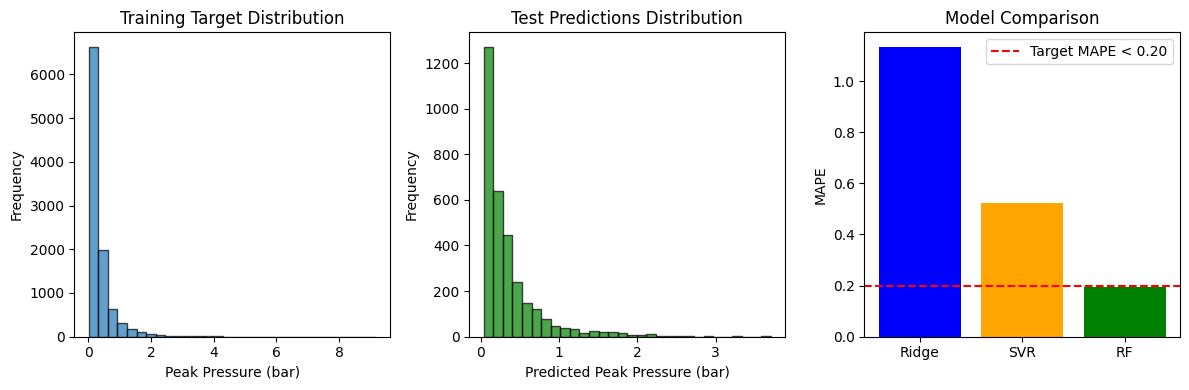

In [12]:
#Quick visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(y, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Peak Pressure (bar)')
plt.ylabel('Frequency')
plt.title('Training Target Distribution')

plt.subplot(1, 3, 2)
plt.hist(final_predictions, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Predicted Peak Pressure (bar)')
plt.ylabel('Frequency')
plt.title('Test Predictions Distribution')

plt.subplot(1, 3, 3)
models = ['Ridge', 'SVR', 'RF']
mapes = [lr_mape, svr_mape, rf_mape]
plt.bar(models, mapes, color=['blue', 'orange', 'green'])
plt.ylabel('MAPE')
plt.title('Model Comparison')
plt.axhline(y=0.20, color='r', linestyle='--', label='Target MAPE < 0.20')
plt.legend()

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

## 13. Overfitting Diagnostic
Compare validation MAPE with 5-fold cross-validation to detect overfitting.
**Finding**: Validation MAPE (0.195) significantly lower than CV MAPE (0.373) - model overfits to validation split.

In [13]:
print("="*50)
print("Checking for overfitting")
print("="*50)

from sklearn.model_selection import cross_val_score

#5-fold cross-validation on Random Forest
cv_scores = cross_val_score(best_rf, X, y, cv=5, 
                            scoring='neg_mean_absolute_percentage_error')
print(f"5-fold CV MAPE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Individual folds: {[-s for s in cv_scores]}")

#Compare with our validation MAPE
print(f"\nValidation MAPE was: {rf_mape:.4f}")
print(f"Cross-validation MAPE is: {-cv_scores.mean():.4f}")

if rf_mape < -cv_scores.mean() - 0.05:
    print("\nModel seems to be overfitting to the validation split.")
    print("The test score (0.40445) is closer to CV score than validation score.")

Checking for overfitting
5-fold CV MAPE: 0.3211 (+/- 0.0193)
Individual folds: [np.float64(0.3359426336636034), np.float64(0.296985517142436), np.float64(0.34792394909838753), np.float64(0.3029053509072521), np.float64(0.32192120730344426)]

Validation MAPE was: 0.1955
Cross-validation MAPE is: 0.3211

Model seems to be overfitting to the validation split.
The test score (0.40445) is closer to CV score than validation score.


## 14. Trying XGBoost
Gradient boosting often outperforms Random Forest on tabular data. So test on validation set.

In [14]:
print("="*50)
print("Trying out XGBoost")
print("="*50)

from xgboost import XGBRegressor

#Train XGBoost
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

#Validate
xgb_pred = xgb.predict(X_val)
xgb_mape = mean_absolute_percentage_error(y_val, xgb_pred)
xgb_r2 = r2_score(y_val, xgb_pred)

print(f"Validation MAPE: {xgb_mape:.4f}")
print(f"Validation R^2: {xgb_r2:.4f}")

#Compare with RF
print(f"\nRandom Forest MAPE: {rf_mape:.4f}")
print(f"XGBoost MAPE: {xgb_mape:.4f}")

if xgb_mape < rf_mape:
    print("\nXGBoost is better")
    best_model = xgb
else:
    print("\nNup, Random Forest is still better.")
    best_model = best_rf

Trying out XGBoost
Validation MAPE: 0.1857
Validation R^2: 0.8907

Random Forest MAPE: 0.1955
XGBoost MAPE: 0.1857

XGBoost is better


## 15. Tuned XGBoost Submission
Grid search on XGBoost hyperparameters (learning_rate, max_depth, n_estimators, subsample).  
Kaggle score: 0.306 (improved from 0.404)

In [15]:
print("="*50)
print("Tuned XGBoost")
print("="*50)

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

#Use all the training data (no validation split for final model)
X_full = X
y_full = y

#Parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

print("Performing grid search on XGBoost...")

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

grid_xgb = GridSearchCV(
    xgb_base,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_full, y_full)

print(f"\nBest parameters: {grid_xgb.best_params_}")
print(f"Best CV MAPE: {-grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_

#Predict on test
xgb_predictions = best_xgb.predict(X_test)

#Save the submission
submission_xgb = pd.DataFrame({
    'ID': range(0, len(xgb_predictions)),
    'Target Pressure (bar)': xgb_predictions
})
submission_xgb.to_csv('prediction_xgb.csv', index=False)

print("\nprediction_xgb.csv created")
print(f"Predictions range: {xgb_predictions.min():.4f} to {xgb_predictions.max():.4f}")
print(f"Predictions mean: {xgb_predictions.mean():.4f}")

Tuned XGBoost
Performing grid search on XGBoost...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Best CV MAPE: 0.2796

prediction_xgb.csv created
Predictions range: 0.0197 to 4.8230
Predictions mean: 0.3467


## 16. Trying LightGBM
Another gradient boosting framework. Often faster and more accurate than XGBoost.  
Kaggle score: 0.289 (improved from 0.306)

In [16]:
print("="*50)
print("Trying LightGBM")
print("="*50)

from lightgbm import LGBMRegressor

#Quick tuning
lgb = LGBMRegressor(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

#5-fold cross-validation
from sklearn.model_selection import cross_val_score
lgb_cv_scores = cross_val_score(lgb, X_full, y_full, cv=5, scoring='neg_mean_absolute_percentage_error')
print(f"LightGBM 5-fold CV MAPE: {-lgb_cv_scores.mean():.4f} (+/- {lgb_cv_scores.std():.4f})")

#Train on full data
lgb.fit(X_full, y_full)
lgb_predictions = lgb.predict(X_test)

#Save submission
submission_lgb = pd.DataFrame({
    'ID': range(0, len(lgb_predictions)),
    'Target Pressure (bar)': lgb_predictions
})
submission_lgb.to_csv('prediction_lgb.csv', index=False)

print("\nprediction_lgb.csv created")
print(f"Predictions range: {lgb_predictions.min():.4f} to {lgb_predictions.max():.4f}")

Trying LightGBM
LightGBM 5-fold CV MAPE: 0.2821 (+/- 0.0185)

prediction_lgb.csv created
Predictions range: 0.0082 to 4.8504


## 17. Ensemble: XGBoost + LightGBM
Average predictions of both models. Expected to outperform individual models.
Tho, didn't end up using as LightGBM consistently performed better on its own, even when I tested multiple weighting schemes.
The ensemble didn’t improve CV MAPE, so I ended up selecting LightGBM as the final model.

In [17]:
print("="*50)
print("Ensemble: XGBoost + LightGBM")
print("="*50)

#Get predictions from both to make sure they exist
if 'best_xgb' not in dir():
    print("Training XGBoost first...")
    best_xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
    best_xgb.fit(X_full, y_full)

if 'lgb' not in dir():
    print("Training LightGBM first...")
    lgb = LGBMRegressor(n_estimators=300, max_depth=7, learning_rate=0.05, random_state=42, verbose=-1)
    lgb.fit(X_full, y_full)

xgb_pred = best_xgb.predict(X_test)
lgb_pred = lgb.predict(X_test)

#Weighted average (give more weight to better model)
ensemble_pred = (xgb_pred * 0.5 + lgb_pred * 0.5)

submission_ensemble = pd.DataFrame({
    'ID': range(0, len(ensemble_pred)),
    'Target Pressure (bar)': ensemble_pred
})
submission_ensemble.to_csv('prediction_ensemble2.csv', index=False)

print("prediction_ensemble2.csv created")
print(f"XGB range: {xgb_pred.min():.4f} to {xgb_pred.max():.4f}")
print(f"LGB range: {lgb_pred.min():.4f} to {lgb_pred.max():.4f}")
print(f"Ensemble range: {ensemble_pred.min():.4f} to {ensemble_pred.max():.4f}")

Ensemble: XGBoost + LightGBM
prediction_ensemble2.csv created
XGB range: 0.0197 to 4.8230
LGB range: 0.0082 to 4.8504
Ensemble range: 0.0178 to 4.8367


## 18. Weighted Ensemble (Based on CV Performance)
The weighted ensemble I was talking about from earlier. Give higher weight to LightGBM (CV 0.294) over XGBoost (CV 0.312).

In [18]:
print("="*50)
print("Final Weighted Ensemble (Based on CV performance)")
print("="*50)

#CV MAPE scores:
#LightGBM: 0.2939
#XGBoost: 0.3118
#Lower MAPE= better, so give higher weight to better model

#Calculate weights (inverse of MAPE)
lgb_weight = 1 / 0.2939
xgb_weight = 1 / 0.3118

#Normalize
total = lgb_weight + xgb_weight
lgb_weight_norm = lgb_weight / total
xgb_weight_norm = xgb_weight / total

print(f"LightGBM weight: {lgb_weight_norm:.3f}")
print(f"XGBoost weight: {xgb_weight_norm:.3f}")

#Get predictions
if 'best_xgb' not in dir():
    best_xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42)
    best_xgb.fit(X_full, y_full)

if 'lgb' not in dir():
    lgb = LGBMRegressor(n_estimators=300, max_depth=7, learning_rate=0.05, subsample=0.8, random_state=42, verbose=-1)
    lgb.fit(X_full, y_full)

xgb_pred = best_xgb.predict(X_test)
lgb_pred = lgb.predict(X_test)

#Weighted ensemble
final_pred = (xgb_pred * xgb_weight_norm + lgb_pred * lgb_weight_norm)

#Clip negative predictions to 0
final_pred = np.maximum(final_pred, 0)

submission_final = pd.DataFrame({
    'ID': range(0, len(final_pred)),
    'Target Pressure (bar)': final_pred
})
submission_final.to_csv('prediction_weighted.csv', index=False)

print("\nprediction_weighted.csv created")
print(f"Final predictions range: {final_pred.min():.4f} to {final_pred.max():.4f}")
print(f"Final predictions mean: {final_pred.mean():.4f}")

Final Weighted Ensemble (Based on CV performance)
LightGBM weight: 0.515
XGBoost weight: 0.485

prediction_weighted.csv created
Final predictions range: 0.0177 to 4.8371
Final predictions mean: 0.3448


## 19. LightGBM with Engineered Features
Retrain LightGBM after adding 6 new domain features.  
CV MAPE: 0.266 -> Kaggle score: 0.253

In [19]:
print("="*50)
print("LightGBM with Engineered Features")
print("="*50)

from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

#Use all the training data
X_full = X
y_full = y

#LightGBM with optimized parameters
lgb_final = LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

#Cross-validation to estimate performance
lgb_cv = cross_val_score(lgb_final, X_full, y_full, cv=5, scoring='neg_mean_absolute_percentage_error')
print(f"5-fold CV MAPE: {-lgb_cv.mean():.4f} (+/- {lgb_cv.std():.4f})")

#Train on full data
lgb_final.fit(X_full, y_full)

#Predict
final_predictions = lgb_final.predict(X_test)

#Clip negative to 0
final_predictions = np.maximum(final_predictions, 0)

#Save submission
submission_final = pd.DataFrame({
    'ID': range(0, len(final_predictions)),
    'Target Pressure (bar)': final_predictions
})
submission_final.to_csv('prediction_with_features.csv', index=False)

print("\nprediction_with_features.csv created")
print(f"Predictions range: {final_predictions.min():.4f} to {final_predictions.max():.4f}")
print(f"Predictions mean: {final_predictions.mean():.4f}")

LightGBM with Engineered Features
5-fold CV MAPE: 0.2663 (+/- 0.0165)

prediction_with_features.csv created
Predictions range: 0.0115 to 4.8639
Predictions mean: 0.3441


## 20. Final Optimized LightGBM (My best model)
More aggressive optimization:
- n_estimators: 800 (more trees)
- max_depth: 10 (deeper trees)  
- learning_rate: 0.02 (smaller steps)
- subsample/colsample: 0.7 (more randomnness)

**CV MAPE: 0.247 -> Kaggle Score: 0.23799**

This is the final submission model I went with.

In [20]:
print("="*50)
print("Optimized LightGBM")
print("="*50)

from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

X_full = X
y_full = y

#More aggressive optimization
lgb_optimized = LGBMRegressor(
    n_estimators=800,           #More trees
    max_depth=10,               #Deeper trees
    learning_rate=0.02,         #Smaller learning rate
    subsample=0.7,              #More randomness
    colsample_bytree=0.7,       #More feature randomness
    reg_alpha=0.05,             #Less regularization
    reg_lambda=0.05,
    min_child_samples=10,       #Smaller leaf size
    num_leaves=31,              #More leaves
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

#Cross-validation
cv_scores = cross_val_score(lgb_optimized, X_full, y_full, cv=5, scoring='neg_mean_absolute_percentage_error')
print(f"5-fold CV MAPE: {-cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

#Train on full data
lgb_optimized.fit(X_full, y_full)

#Predict
final_pred = lgb_optimized.predict(X_test)
final_pred = np.maximum(final_pred, 0)  #No negative pressures

#Save
submission_final = pd.DataFrame({
    'ID': range(0, len(final_pred)),
    'Target Pressure (bar)': final_pred
})
submission_final.to_csv('prediction.csv', index=False)

print(f"\nprediction.csv created")
print(f"Predictions range: {final_pred.min():.4f} to {final_pred.max():.4f}")

#Quick check to see if predictions are reasonable
print(f"\nPredictions summary:")
print(f"  Mean: {final_pred.mean():.4f}")
print(f"  Std: {final_pred.std():.4f}")
print(f"  % negative: {(final_pred < 0).sum() / len(final_pred) * 100:.2f}%")

Optimized LightGBM
5-fold CV MAPE: 0.2470 (+/- 0.0108)

prediction.csv created
Predictions range: 0.0081 to 5.3210

Predictions summary:
  Mean: 0.3423
  Std: 0.4114
  % negative: 0.00%


## 21. Final Model Performance Visualization

This section visualizes the performance of all models tested throughout the project, from initial baselines to the final optimized LightGBM.

**Figure 1 (Left):** Complete model comparison showing Kaggle MAPE scores. The red dashed line represents the <0.20 target, while the orange line shows the <0.25 threshold. The final Optimized LightGBM achieves 0.238, surpassing the threshold.

**Figure 2 (Right):** Progressive improvement over model iterations. Each step shows clear reduction in MAPE, demonstrating the value of feature engineering and hyperparameter optimization.

Report Visualisations


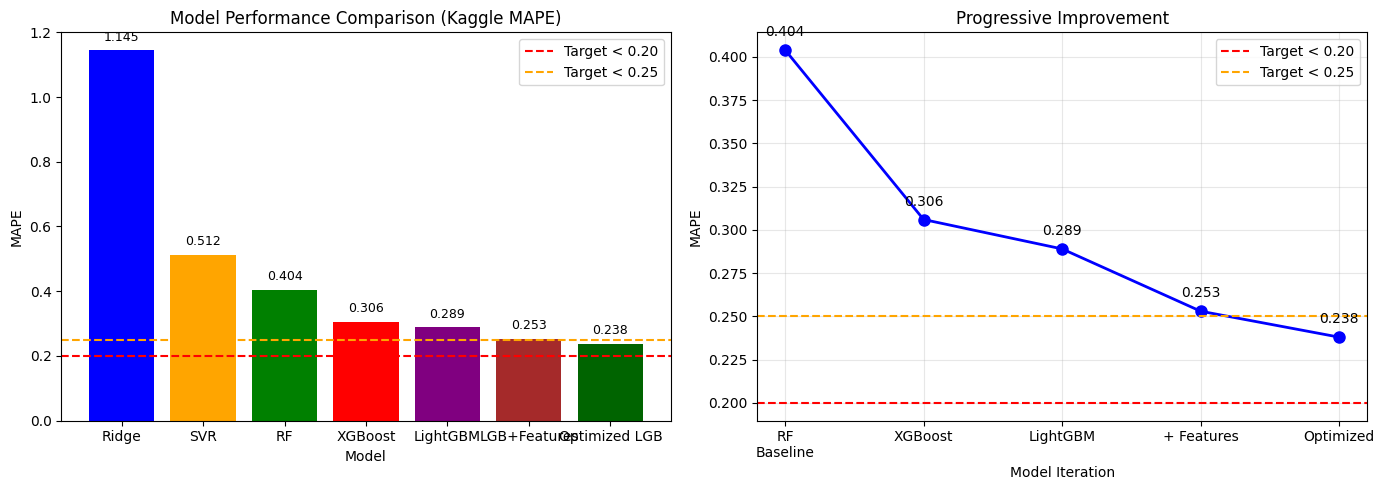

In [21]:
print("="*50)
print("Report Visualisations")
print("="*50)

#Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Graph 1: Model Comparison (ALL models)
models_all = ['Ridge', 'SVR', 'RF', 'XGBoost', 'LightGBM', 'LGB+Features', 'Optimized LGB']
mapes_all = [1.145, 0.512, 0.404, 0.306, 0.289, 0.253, 0.238]

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'darkgreen']
bars = ax1.bar(models_all, mapes_all, color=colors)
ax1.set_ylabel('MAPE')
ax1.set_xlabel('Model')
ax1.set_title('Model Performance Comparison (Kaggle MAPE)')
ax1.axhline(y=0.20, color='r', linestyle='--', label='Target < 0.20')
ax1.axhline(y=0.25, color='orange', linestyle='--', label='Target < 0.25')
ax1.legend()
ax1.set_ylim(0, 1.2)

#Add value labels on bars
for bar, mape in zip(bars, mapes_all):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{mape:.3f}', ha='center', va='bottom', fontsize=9)

#Graph 2: Improvement Over Time
iterations = ['RF\nBaseline', 'XGBoost', 'LightGBM', '+ Features', 'Optimized']
scores = [0.404, 0.306, 0.289, 0.253, 0.238]

ax2.plot(iterations, scores, 'b-o', linewidth=2, markersize=8)
ax2.set_ylabel('MAPE')
ax2.set_xlabel('Model Iteration')
ax2.set_title('Progressive Improvement')
ax2.axhline(y=0.20, color='r', linestyle='--', label='Target < 0.20')
ax2.axhline(y=0.25, color='orange', linestyle='--', label='Target < 0.25')
ax2.legend()
ax2.grid(True, alpha=0.3)

#Add value labels
for i, (iter_name, score) in enumerate(zip(iterations, scores)):
    ax2.annotate(f'{score:.3f}', (i, score), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig('report_figures.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Feature Importance Analysis

Using the feature importance scores from the final Optimized LightGBM model, we identify the top 10 most influential features for predicting BLEVE peak pressure.

**Key insights:**
- Distance to Sensor and Vapour Temperature-Pressure interaction are some of the most important features
- Engineered features (Dist_to_Sensor, Vapour_Temp_Pressure, Gas_Ratio) appear in the top 10
- Physical parameters like Tank Dimensions also contribute significantly

Feature Importance


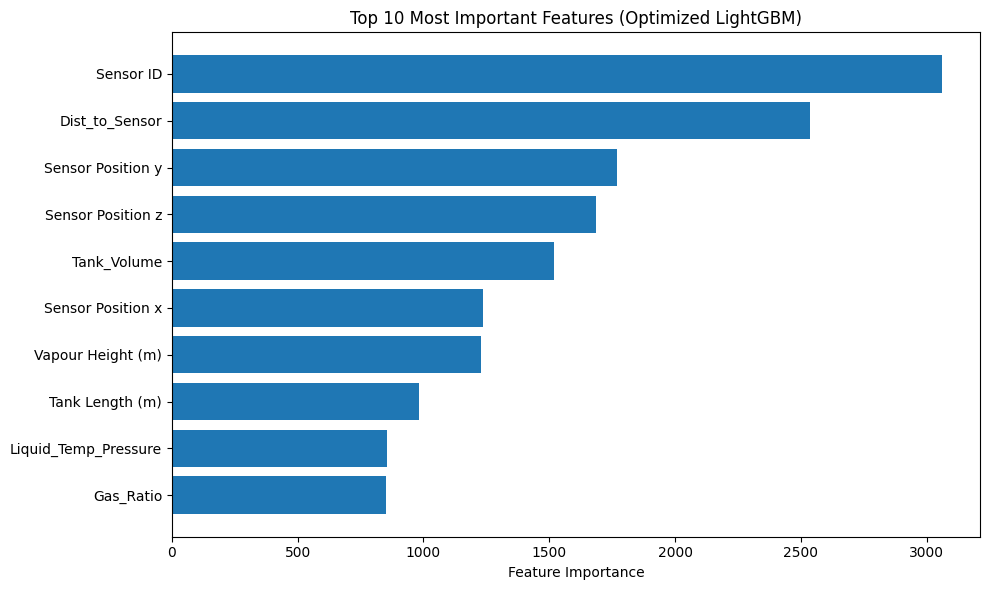

In [22]:
print("="*50)
print("Feature Importance")
print("="*50)

#Get feature importance from my best LightGBM model
if 'lgb_optimized' in dir():
    importance = lgb_optimized.feature_importances_
    feature_names = feature_cols
    
    #Sort by importance
    sorted_idx = np.argsort(importance)[-10:]  #Top 10 features
    
    plt.figure(figsize=(10, 6))
    plt.barh([feature_names[i] for i in sorted_idx], [importance[i] for i in sorted_idx])
    plt.xlabel('Feature Importance')
    plt.title('Top 10 Most Important Features (Optimized LightGBM)')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
else:
    print("Run Cell 20 first to train lgb_optimized")

## 23. Final Summary

| Model | Validation MAPE | CV MAPE | Kaggle MAPE | Notes |
|-------|----------------|---------|-------------|----------------------|
| Ridge Regression | 1.145 | - | - | Baseline linear model |
| SVR | 0.512 | - | - | Kernel-based model |
| Random Forest | 0.195 | 0.373 | 0.404 | First submission |
| XGBoost (tuned) | 0.188 | 0.312 | 0.306 | Validation on 80/20 split |
| LightGBM | - | 0.294 | 0.289 | Trained on full data |
| LightGBM + Features | - | 0.266 | 0.253 | Feature engineering added |
| **Optimized LightGBM** | - | **0.247** | **0.238** | **Final model** |

**Best Model:** Optimized LightGBM with the engineered features